# Tier B / S3 — the mixed-bed erosion threshold

**Reference.** Sherwood, C. R. *et al.* (2018), *Cohesive and mixed sediment in
the Regional Ocean Modeling System (ROMS v3.6) implemented in COAWST*,
Geosci. Model Dev. **11**, 1849–1871 — Section 2.6 and Figure 2.

**What this tests.** How the erosion threshold of a *mixed* bed — sand and mud
together — depends on how much mud is present. This is a pure closure comparison:
no simulation is run, so it is instant, and it isolates one equation.

**The physical picture.** A bed with only a few per cent mud behaves like sand:
each grain is held by its own weight, and fines are winnowed out easily. Above
roughly 3–30 % mud the bed starts behaving as a *bulk* cohesive material: the mud
matrix binds everything, so even coarse grains are held by the mud's strength
rather than their own.

**Sherwood's Eq. 6:**

$$ \tau_{ce} = \max\!\left[\,P_c\,\tau_{cb} + (1-P_c)\,\tau_c\ ,\ \tau_c\,\right] $$

with $P_c$ the cohesive-behaviour parameter (0 = non-cohesive, 1 = cohesive),
$\tau_{cb}$ the **bulk** critical stress of the bed — *one number for every size
class* — and $\tau_c$ the particle's own Shields stress. Note the `max`: making a
bed muddier can never make a grain *easier* to erode.

**What we do instead** (`sedimentdrift.py`, mode `mixed`):

$$ \tau_{crit} = (1-P_c)\,\tau_{\rm Shields}(d) + P_c\,\tau_{\rm floc}(d, D_f, \phi) $$

Both terms are per-particle, and $\tau_{\rm floc} \propto d$. This notebook shows
what that difference costs.

Test: `tests/models/test_sppm_roms_cases.py` (the `test_s3_*` family)

In [1]:
# Tier B / S3 - mixed-bed erosion threshold
import sys, pathlib, warnings
warnings.filterwarnings("ignore")

# locate the repository root (the directory containing `opendrift/`)
_p = pathlib.Path.cwd().resolve()
while not (_p / "opendrift" / "__init__.py").exists() and _p != _p.parent:
    _p = _p.parent
REPO = _p
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

plt.rcParams.update({
    "figure.figsize": (9, 4.2), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
})
CLR = ["#0b6fa4", "#e07b39", "#3f9b52", "#b4434e", "#7c5aa6"]
print("repo:", REPO)

repo: /home/smullersoares/projects/software/opendrift


## Setup

The four sediment classes of Sherwood's experiments, and the Figure 2
configuration: bulk bed stress $\tau_{cb} = 0.1$ Pa, applied bottom stress
$\tau_b = 0.12$ Pa.

In [2]:
from tests.models.test_sppm_roms_cases import (
    CLASS_D, CLASS_TAU_CE, CLASS_WS, TAU_CB, TAU_B,
    sherwood_tau_ce, _shields, _model_mixed_tau)

NAMES = ['clay 4 µm', 'silt 30 µm', 'sand 62.5 µm', 'sand 140 µm']
tau_c = _shields(CLASS_D)

print(f"{'class':>14s} {'d [µm]':>8s} {'w_s [mm/s]':>11s} {'Shields τ_c [Pa]':>17s}")
for n, d, w, t in zip(NAMES, CLASS_D, CLASS_WS, tau_c):
    print(f"{n:>14s} {d*1e6:8.1f} {w*1e3:11.2f} {t:17.4f}")
print(f"\nbulk bed stress τ_cb = {TAU_CB} Pa;  applied stress τ_b = {TAU_B} Pa")

         class   d [µm]  w_s [mm/s]  Shields τ_c [Pa]
     clay 4 µm      4.0        0.10            0.0174
    silt 30 µm     30.0        0.60            0.0831
  sand 62.5 µm     62.5        2.00            0.1198
   sand 140 µm    140.0        8.00            0.1585

bulk bed stress τ_cb = 0.1 Pa;  applied stress τ_b = 0.12 Pa


### The cohesive-behaviour ramp

$P_c$ rises from 0 to 1 as the bed's mud fraction increases. Our ramp runs over
5 %→35 % mud (from Jacobs *et al.* 2011 and Yao *et al.* 2022); Sherwood's Figure 2
example completes at 20 %. That difference is minor next to what follows.

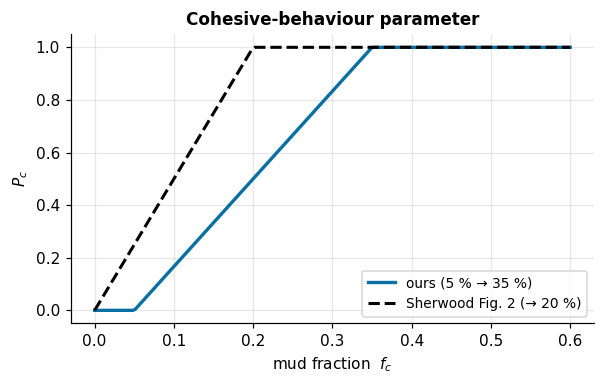

In [3]:
fmud = np.linspace(0, 0.6, 200)
Pc_ours = np.clip((fmud - 0.05) / (0.35 - 0.05), 0, 1)
Pc_sher = np.clip(fmud / 0.20, 0, 1)

fig, ax = plt.subplots(figsize=(5.6, 3.6))
ax.plot(fmud, Pc_ours, color=CLR[0], lw=2.2, label='ours (5 % → 35 %)')
ax.plot(fmud, Pc_sher, color='k', lw=2, ls='--', label='Sherwood Fig. 2 (→ 20 %)')
ax.set_xlabel('mud fraction  $f_c$'); ax.set_ylabel('$P_c$')
ax.set_title('Cohesive-behaviour parameter')
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

## Result — the two formulations side by side

Left: Sherwood Eq. 6. Every class converges toward the *same* bulk bed stress,
floored at its own Shields value, so the curves fan into a narrow band.

Right: ours. Because the cohesive term scales with each particle's **own**
diameter, the classes fan *apart* — a 140 µm grain in a muddy bed is assigned the
fictitious strength of a 140 µm floc.

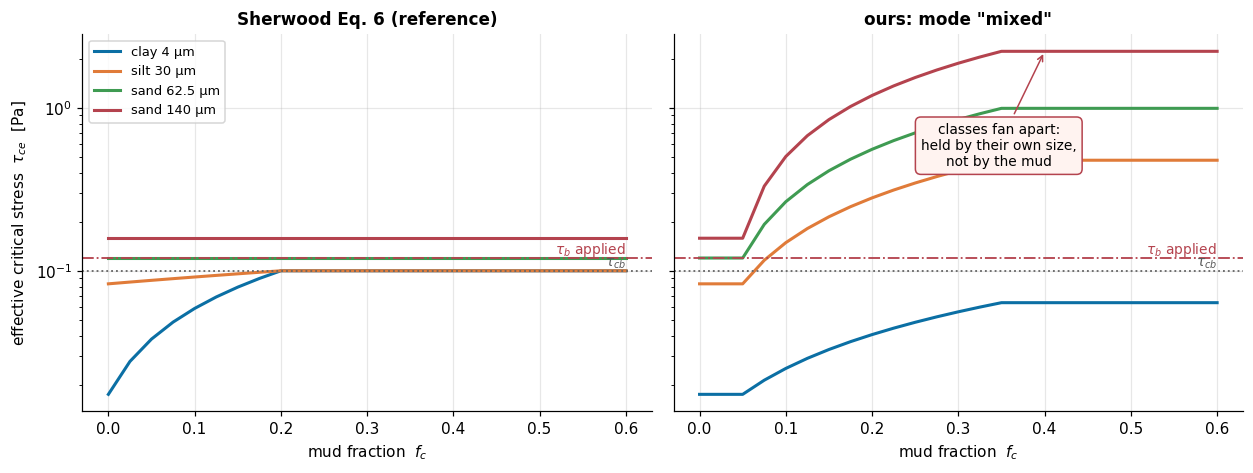

In [4]:
fm = np.linspace(0, 0.6, 25)
ours = np.array([_model_mixed_tau(f, CLASS_D) for f in fm])
sher = np.array([sherwood_tau_ce(np.clip(f / 0.20, 0, 1), TAU_CB, tau_c) for f in fm])

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.5, 4.4), sharey=True)
for k, (n, c) in enumerate(zip(NAMES, CLR)):
    a1.plot(fm, sher[:, k], color=c, lw=2, label=n)
    a2.plot(fm, ours[:, k], color=c, lw=2, label=n)
for a, t in ((a1, 'Sherwood Eq. 6 (reference)'), (a2, 'ours: mode "mixed"')):
    a.axhline(TAU_CB, color='0.4', lw=1.2, ls=':')
    a.text(0.60, TAU_CB * 1.06, r'$\tau_{cb}$', ha='right', fontsize=9, color='0.35')
    a.axhline(TAU_B, color=CLR[3], lw=1.2, ls='-.')
    a.text(0.60, TAU_B * 1.06, r'$\tau_b$ applied', ha='right', fontsize=9, color=CLR[3])
    a.set_yscale('log'); a.set_xlabel('mud fraction  $f_c$'); a.set_title(t)
a1.set_ylabel(r'effective critical stress  $\tau_{ce}$  [Pa]')
a1.legend(fontsize=8.5, loc='upper left')
a2.annotate('classes fan apart:\nheld by their own size,\nnot by the mud',
            xy=(0.40, ours[-6, 3]), xytext=(-30, -75), textcoords='offset points',
            fontsize=9, ha='center',
            arrowprops=dict(arrowstyle='->', color=CLR[3]),
            bbox=dict(boxstyle='round,pad=0.4', fc='#fff3f0', ec=CLR[3]))
plt.tight_layout(); plt.show()

### How large is the error?

In the fully cohesive limit ($P_c = 1$), against Eq. 6:

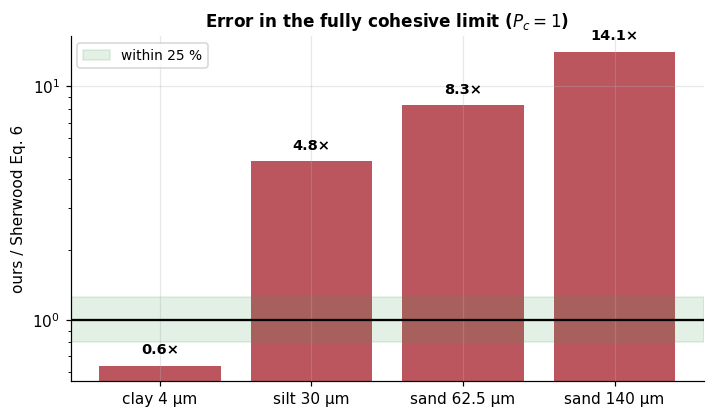

         class  Eq.6 [Pa]  ours [Pa]   ratio
     clay 4 µm      0.100      0.064    0.6×
    silt 30 µm      0.100      0.478    4.8×
  sand 62.5 µm      0.120      0.995    8.3×
   sand 140 µm      0.159      2.229   14.1×


In [5]:
o_lim = _model_mixed_tau(0.5, CLASS_D)
s_lim = sherwood_tau_ce(1.0, TAU_CB, tau_c)
ratio = o_lim / s_lim

fig, ax = plt.subplots(figsize=(6.6, 3.9))
cols = [CLR[2] if 0.8 < r < 1.25 else CLR[3] for r in ratio]
ax.bar(NAMES, ratio, color=cols, alpha=.9)
ax.axhline(1, color='k', lw=1.5)
ax.axhspan(0.8, 1.25, color=CLR[2], alpha=.15, label='within 25 %')
ax.set_yscale('log'); ax.set_ylabel(r'ours / Sherwood Eq. 6')
ax.set_title(r'Error in the fully cohesive limit ($P_c=1$)')
for i, r in enumerate(ratio):
    ax.text(i, r * 1.12, f'{r:.1f}×', ha='center', fontsize=9.5, fontweight='bold')
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

print(f"{'class':>14s} {'Eq.6 [Pa]':>10s} {'ours [Pa]':>10s} {'ratio':>7s}")
for n, s_, o_, r in zip(NAMES, s_lim, o_lim, ratio):
    print(f"{n:>14s} {s_:10.3f} {o_:10.3f} {r:6.1f}×")

## Verdict — **FAIL (finding F1)**

Two distinct defects, both visible above:

1. **The cohesive term is the wrong quantity.** It should be the bulk stress of
   the bed, identical for every class. Ours is a floc strength computed from the
   *particle's own* diameter, so coarse grains come out up to **14× too hard to
   erode**.
2. **The `max(·, τ_c)` floor is missing.** Without it, making a bed muddier can
   make the finest class *easier* to erode — the clay bar sits at **0.6×**, below
   one.

**What still works:** at low mud fraction the two agree exactly (both reduce to
the particle's Shields stress), and our thresholds do increase monotonically with
mud content. The structure is right; the cohesive limit is not.

**Scope.** `mixed` is not the production default — `auto` is — so the DDT
production runs are not affected *through this path*. But `auto` uses the same
`tau_crit_floc(d)` for everything below its 63 µm cutoff, which is how a 31 µm
quartz grain in those runs acquires a 0.48 Pa threshold against a legacy value of
0.09 Pa. That is consistent with the near-zero resuspension already seen there.

Fix belongs to **M2/B3**. This is pinned in the test suite as a strict `xfail`,
so a fix cannot land without updating the documentation.